# U-Net для semantic segmentation: Carvana Image Masking Challenge

In [1]:
import os, zipfile, time, random, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from sklearn.model_selection import train_test_split

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')
SEED = 42
H, W = 256, 384
EPOCHS = 15
BATCH = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WORK = Path('/kaggle/working')


def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


seed_all()
print(DEVICE, torch.__version__, A.__version__)

cuda 2.11.0+cu128 2.0.8


## 1. Пары изображение–маска

In [2]:
ROOT = Path('/kaggle/input/competitions/carvana-image-masking-challenge')
DATA = Path('/kaggle/working/data')
for z in ('train.zip', 'train_masks.zip'):
    zipfile.ZipFile(ROOT / z).extractall(DATA)

images = {p.stem: p for p in (DATA / 'train').glob('*.jpg')}
masks = {p.stem[:-5]: p for p in (DATA / 'train_masks').glob('*_mask.gif')}

print('изображений:', len(images), '| масок:', len(masks))
print('изображения без маски:', sorted(set(images) - set(masks))[:10])
print('маски без изображения:', sorted(set(masks) - set(images))[:10])

ids = sorted(set(images) & set(masks))
cars = np.array([i.split('_')[0] for i in ids])
print('пар:', len(ids), '| автомобилей:', len(set(cars)), '| ракурсов на авто:', pd.Series(cars).value_counts().unique())


изображений: 5088 | масок: 5088
изображения без маски: []
маски без изображения: []
пар: 5088 | автомобилей: 318 | ракурсов на авто: [16]


Все изображения и маски уменьшаются один раз до 256×384 и хранятся в памяти как uint8 (≈ 2.5 ГБ): так обучение не упирается в декодирование JPEG 1918×1280.
Заодно проверяется, что исходные размеры изображения и маски совпадают.

In [3]:
def load_pair(i):
    im, ms = Image.open(images[i]), Image.open(masks[i]).convert('L')
    same = im.size == ms.size
    im.draft('RGB', (W * 2, H * 2))
    im = np.asarray(im.convert('RGB').resize((W, H), Image.BILINEAR))
    ms = (np.asarray(ms.resize((W, H), Image.BILINEAR)) > 127).astype(np.uint8)
    return im, ms, same


with ThreadPoolExecutor(8) as ex:
    out = list(tqdm(ex.map(load_pair, ids), total=len(ids)))
imgs = np.stack([o[0] for o in out])
msks = np.stack([o[1] for o in out])
print('размеры совпадают у всех пар:', all(o[2] for o in out), '| значения масок:', np.unique(msks), imgs.shape, msks.shape)
del out

  0%|          | 0/5088 [00:00<?, ?it/s]

размеры совпадают у всех пар: True | значения масок: [0 1] (5088, 256, 384, 3) (5088, 256, 384)


## 2. Визуализация

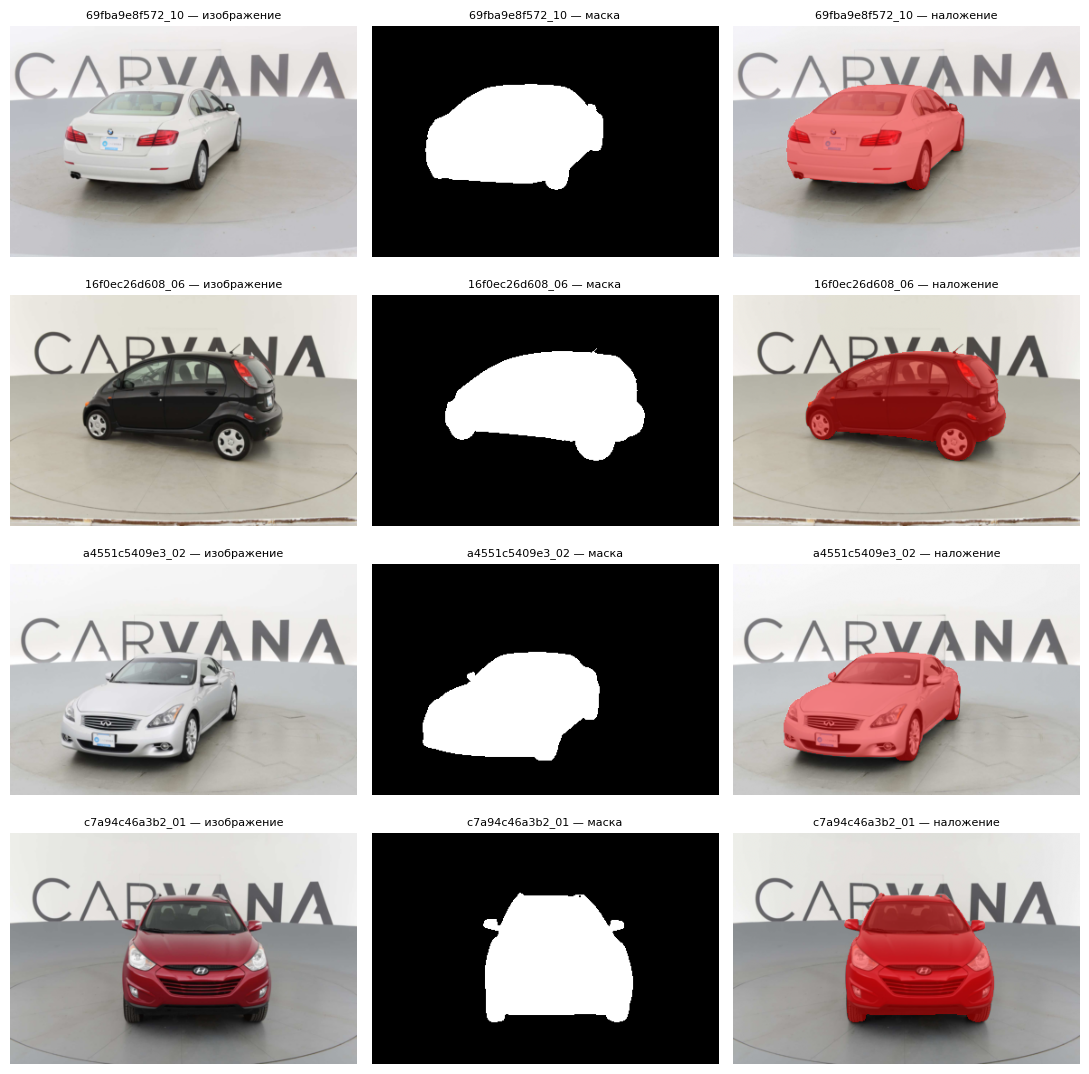

In [4]:
def overlay(img, m, color=(1, 0, 0), a=0.45):
    o = img.astype(float) / 255
    o[m.astype(bool)] = (1 - a) * o[m.astype(bool)] + a * np.array(color)
    return o


rng = np.random.default_rng(SEED)
pick = rng.choice(len(ids), 4, replace=False)
fig, ax = plt.subplots(4, 3, figsize=(11, 11))
for r, k in enumerate(pick):
    for c, (im, t) in enumerate([(imgs[k], 'изображение'), (msks[k], 'маска'), (overlay(imgs[k], msks[k]), 'наложение')]):
        ax[r, c].imshow(im, cmap='gray'); ax[r, c].axis('off')
        ax[r, c].set_title(f'{ids[k]} — {t}', fontsize=8)
plt.tight_layout(); plt.show()

## 3. Доля foreground и дисбаланс пикселей

доля foreground по всем пикселям: 0.211 | фон:foreground = 3.75:1
count    5088.000
mean        0.211
std         0.049
min         0.088
25%         0.178
50%         0.208
75%         0.236
max         0.410
масок с долей foreground < 0.1: 5 | > 0.7: 0


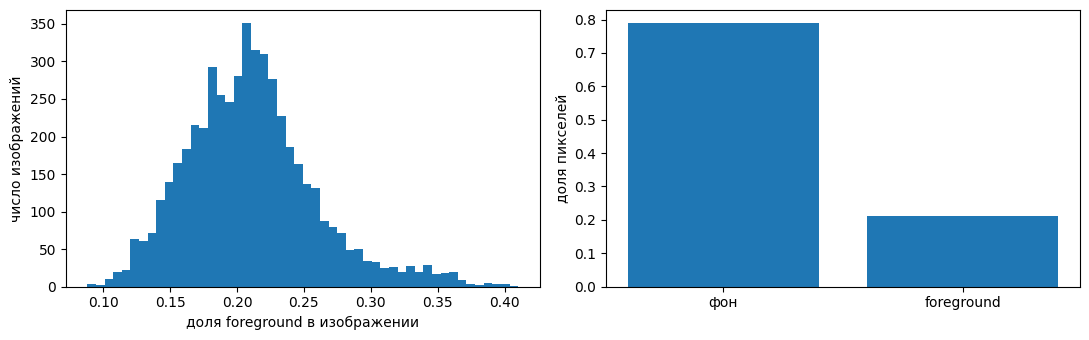

In [5]:
frac = msks.mean((1, 2))
p_fg = msks.mean()
print(f'доля foreground по всем пикселям: {p_fg:.3f} | фон:foreground = {(1 - p_fg) / p_fg:.2f}:1')
print(pd.Series(frac).describe().round(3).to_string())
print('масок с долей foreground < 0.1:', (frac < 0.1).sum(), '| > 0.7:', (frac > 0.7).sum())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(frac, bins=50); ax[0].set_xlabel('доля foreground в изображении'); ax[0].set_ylabel('число изображений')
ax[1].bar(['фон', 'foreground'], [1 - p_fg, p_fg]); ax[1].set_ylabel('доля пикселей')
plt.tight_layout(); plt.show()

## 4. Разбиение до аугментаций

Каждый автомобиль снят с 16 ракурсов, снимки одной машины почти одинаковы. Если разделять по снимкам, один и тот же автомобиль попадёт и в train, и в validation — метрика завысится.
Поэтому делим по идентификатору автомобиля: 70 % train, 15 % validation, 15 % test.

In [6]:
uc = np.array(sorted(set(cars)))
tr_c, rest = train_test_split(uc, test_size=0.3, random_state=SEED)
va_c, te_c = train_test_split(rest, test_size=0.5, random_state=SEED)
tr_idx, va_idx, te_idx = [np.where(np.isin(cars, c))[0] for c in (tr_c, va_c, te_c)]
assert not (set(tr_c) & set(va_c)) and not (set(tr_c) & set(te_c)) and not (set(va_c) & set(te_c))
print('train/val/test изображений:', len(tr_idx), len(va_idx), len(te_idx))
print('средняя доля foreground:', [round(frac[i].mean(), 3) for i in (tr_idx, va_idx, te_idx)])

train/val/test изображений: 3552 768 768
средняя доля foreground: [np.float64(0.214), np.float64(0.198), np.float64(0.208)]


## 5. Dataset и синхронные аугментации

`albumentations` применяет одни и те же случайные параметры crop, resize и flip к изображению и маске; изображение интерполируется билинейно, маска — по ближайшему соседу.

In [7]:
geo = A.Compose([A.RandomResizedCrop(size=(H, W), scale=(0.6, 1.0), ratio=(1.4, 1.6)), A.HorizontalFlip(p=0.5)])
norm = A.Compose([A.Normalize(), ToTensorV2()])
train_tf = A.Compose([geo, A.RandomBrightnessContrast(0.2, 0.2, p=0.3), norm])
val_tf = norm


class CarvanaDS(Dataset):
    def __init__(self, idx, tf):
        self.idx, self.tf = idx, tf

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        r = self.tf(image=imgs[j], mask=msks[j])
        return r['image'], r['mask'].float().unsqueeze(0)


train_dl = DataLoader(CarvanaDS(tr_idx, train_tf), BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True, persistent_workers=True)
val_dl = DataLoader(CarvanaDS(va_idx, val_tf), BATCH, num_workers=2, pin_memory=True, persistent_workers=True)
x, y = next(iter(train_dl))
print(x.shape, y.shape, x.dtype, y.dtype, y.unique())

torch.Size([32, 3, 256, 384]) torch.Size([32, 1, 256, 384]) torch.float32 torch.float32 tensor([0., 1.])


**Проверка геометрии.** В качестве «изображения» подаётся сама маска, повторённая на три канала. Если преобразования синхронны, то после них «изображение», обрезанное по порогу, совпадёт с преобразованной маской.
Расхождение возможно только на границе из-за разной интерполяции.

IoU «изображение–маска» после аугментации: среднее 0.9856, минимум 0.9759


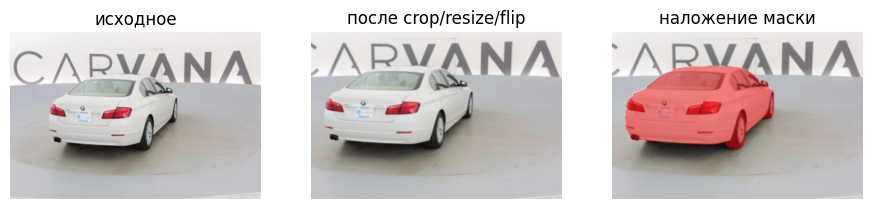

In [8]:
ious = []
for k in rng.choice(len(ids), 100, replace=False):
    m = msks[k]
    r = geo(image=np.repeat(m[..., None] * 255, 3, 2), mask=m)
    a, b = r['image'][..., 0] > 127, r['mask'].astype(bool)
    ious.append((a & b).sum() / max((a | b).sum(), 1))
print(f'IoU «изображение–маска» после аугментации: среднее {np.mean(ious):.4f}, минимум {np.min(ious):.4f}')

k = pick[0]
r = geo(image=imgs[k], mask=msks[k])
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for a, (im, t) in zip(ax, [(imgs[k], 'исходное'), (r['image'], 'после crop/resize/flip'), (overlay(r['image'], r['mask']), 'наложение маски')]):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.show()

## 6. U-Net

In [9]:
def block(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True),
                         nn.Conv2d(o, o, 3, padding=1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True))


class UNet(nn.Module):
    def __init__(self, ch=(16, 32, 64, 128, 256)):
        super().__init__()
        self.enc = nn.ModuleList([block(i, o) for i, o in zip((3,) + ch[:-2], ch[:-1])])
        self.mid = block(ch[-2], ch[-1])
        self.up = nn.ModuleList([nn.ConvTranspose2d(i, o, 2, stride=2) for i, o in zip(ch[:0:-1], ch[-2::-1])])
        self.dec = nn.ModuleList([block(2 * o, o) for o in ch[-2::-1]])
        self.head = nn.Conv2d(ch[0], 1, 1)

    def forward(self, x):
        skips = []
        for e in self.enc:
            x = e(x); skips.append(x); x = F.max_pool2d(x, 2)
        x = self.mid(x)
        for up, dec, s in zip(self.up, self.dec, skips[::-1]):
            x = dec(torch.cat([s, up(x)], 1))
        return self.head(x)


net = UNet()
print(f'параметров: {sum(p.numel() for p in net.parameters()) / 1e6:.2f} M | выход: {net(torch.randn(2, 3, H, W)).shape}')

параметров: 1.94 M | выход: torch.Size([2, 1, 256, 384])


## 7. Функции потерь и метрики

- `BCEWithLogitsLoss` — попиксельная кросс-энтропия, сигмоида внутри.
- BCE + Dice: к BCE добавляется `1 − Dice`, где Dice считается по мягким вероятностям (без порога), отдельно на каждом изображении. Dice слабо зависит от количества фона, поэтому он должен помогать при дисбалансе.

Dice и IoU на validation считаются после сигмоиды и порога, отдельно по изображению, затем усредняются.

In [10]:
bce = nn.BCEWithLogitsLoss()


def dice_loss(logits, y, eps=1.0):
    p, y = torch.sigmoid(logits).flatten(1), y.flatten(1)
    return (1 - (2 * (p * y).sum(1) + eps) / (p.sum(1) + y.sum(1) + eps)).mean()


LOSSES = {'bce': lambda l, y: bce(l, y), 'bce_dice': lambda l, y: bce(l, y) + dice_loss(l, y)}


def dice_iou(prob, y, thr=0.5, eps=1e-7):
    p, y = (prob.float() > thr).flatten(1).float(), y.flatten(1).float()
    inter, s = (p * y).sum(1), p.sum(1) + y.sum(1)
    return (2 * inter + eps) / (s + eps), (inter + eps) / (s - inter + eps)


def evaluate(model, loss_fn):
    model.eval(); L, LB, D, I = [], [], [], []
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=DEVICE == 'cuda'):
                lg = model(x)
            lg = lg.float()
            d, i = dice_iou(torch.sigmoid(lg), y)
            L.append(loss_fn(lg, y).item()); LB.append(bce(lg, y).item()); D.append(d); I.append(i)
    return np.mean(L), np.mean(LB), torch.cat(D).mean().item(), torch.cat(I).mean().item()

## 8. Обучение: BCE и BCE + Dice

In [11]:
def fit(name, loss_fn, epochs=EPOCHS):
    seed_all()
    model = UNet().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), 1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, 3e-3, total_steps=epochs * len(train_dl))
    scaler = torch.amp.GradScaler(enabled=DEVICE == 'cuda')
    hist, best = [], -1
    for ep in range(epochs):
        model.train(); t0, tl = time.time(), []
        for x, y in train_dl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.autocast(DEVICE, dtype=torch.float16, enabled=DEVICE == 'cuda'):
                lg = model(x)
            loss = loss_fn(lg.float(), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            tl.append(loss.item())
        vl, vb, vd, vi = evaluate(model, loss_fn)
        hist.append(dict(epoch=ep + 1, train_loss=np.mean(tl), val_loss=vl, val_bce=vb, val_dice=vd, val_iou=vi))
        if vd > best:
            best = vd; torch.save(model.state_dict(), WORK / f'{name}.pt')
        print(f'{name} ep{ep + 1:02d} train {np.mean(tl):.4f} val {vl:.4f} dice {vd:.4f} iou {vi:.4f} ({time.time() - t0:.0f}s)')
    model.load_state_dict(torch.load(WORK / f'{name}.pt'))
    return model, pd.DataFrame(hist)


models, hists = {}, {}
for name, fn in LOSSES.items():
    models[name], hists[name] = fit(name, fn)

bce ep01 train 0.4029 val 0.2905 dice 0.9601 iou 0.9235 (28s)
bce ep02 train 0.2147 val 0.1322 dice 0.9751 iou 0.9515 (26s)
bce ep03 train 0.0855 val 0.0800 dice 0.9482 iou 0.9022 (27s)
bce ep04 train 0.0664 val 0.0350 dice 0.9749 iou 0.9511 (27s)
bce ep05 train 0.0336 val 0.0264 dice 0.9788 iou 0.9585 (28s)
bce ep06 train 0.0250 val 0.0174 dice 0.9862 iou 0.9728 (28s)
bce ep07 train 0.0217 val 0.0158 dice 0.9858 iou 0.9720 (29s)
bce ep08 train 0.0196 val 0.0132 dice 0.9882 iou 0.9768 (29s)
bce ep09 train 0.0175 val 0.0117 dice 0.9894 iou 0.9789 (30s)
bce ep10 train 0.0160 val 0.0110 dice 0.9898 iou 0.9798 (30s)
bce ep11 train 0.0148 val 0.0113 dice 0.9893 iou 0.9788 (30s)
bce ep12 train 0.0145 val 0.0108 dice 0.9895 iou 0.9793 (30s)
bce ep13 train 0.0139 val 0.0110 dice 0.9892 iou 0.9786 (31s)
bce ep14 train 0.0135 val 0.0103 dice 0.9900 iou 0.9801 (31s)
bce ep15 train 0.0134 val 0.0104 dice 0.9899 iou 0.9800 (31s)
bce_dice ep01 train 0.8596 val 0.7286 dice 0.9322 iou 0.8737 (32s)
bce

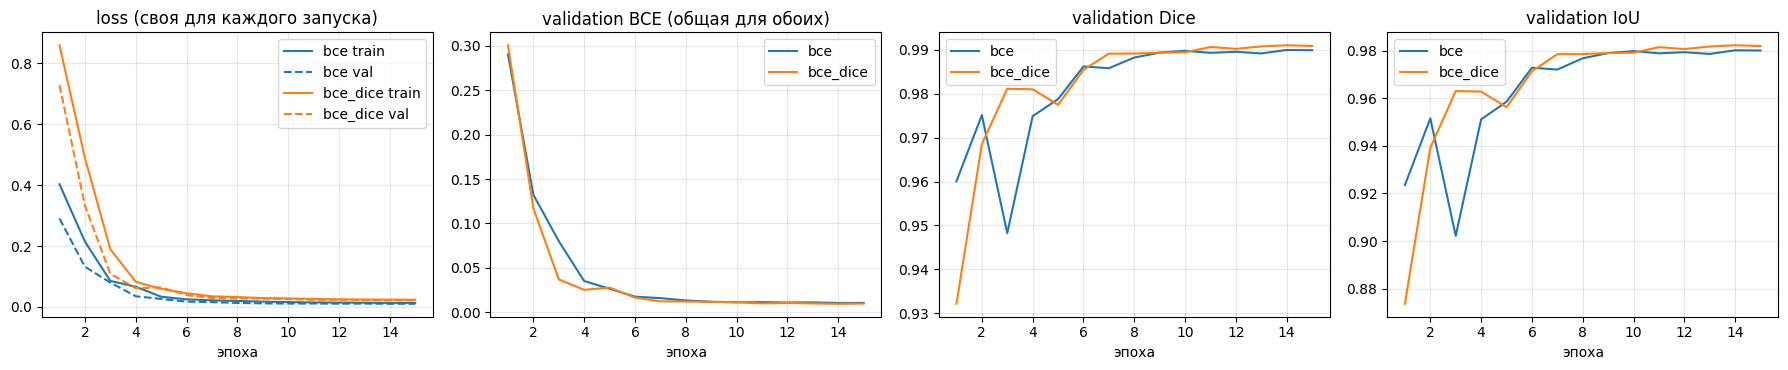

,epoch,train_loss,val_loss,val_bce,val_dice,val_iou
bce,14.0,0.0135,0.0103,0.0103,0.990,0.9801
bce_dice,14.0,0.0242,0.0220,0.0094,0.991,0.9822


In [12]:
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
col = {'bce': 'tab:blue', 'bce_dice': 'tab:orange'}
for n, h in hists.items():
    ax[0].plot(h.epoch, h.train_loss, color=col[n], label=f'{n} train'); ax[0].plot(h.epoch, h.val_loss, '--', color=col[n], label=f'{n} val')
    ax[1].plot(h.epoch, h.val_bce, color=col[n], label=n)
    ax[2].plot(h.epoch, h.val_dice, color=col[n], label=n)
    ax[3].plot(h.epoch, h.val_iou, color=col[n], label=n)
for a, t in zip(ax, ['loss (своя для каждого запуска)', 'validation BCE (общая для обоих)', 'validation Dice', 'validation IoU']):
    a.set_title(t); a.set_xlabel('эпоха'); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

pd.DataFrame({n: h.loc[h.val_dice.idxmax()] for n, h in hists.items()}).T.round(4)

## 9. Порог по validation

Модель выдаёт вероятность «пиксель — автомобиль». Порог превращает её в маску: вероятность выше порога — foreground.
Порог подбирается по среднему Dice на validation; test в подборе не участвует.

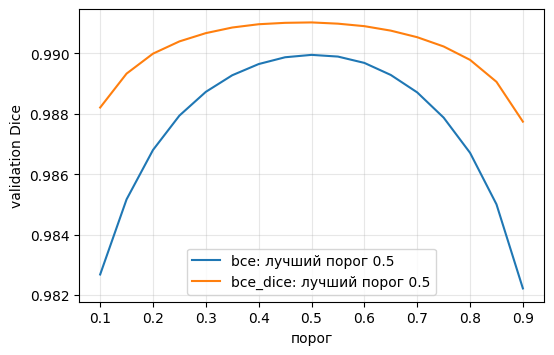

,loss,split,порог,thr,dice,iou
0,bce,val,0.5,0.5,0.9900,0.9801
1,bce,val,подобранный,0.5,0.9900,0.9801
2,bce,test,0.5,0.5,0.9897,0.9796
3,bce,test,подобранный,0.5,0.9897,0.9796
4,bce_dice,val,0.5,0.5,0.9910,0.9822
5,bce_dice,val,подобранный,0.5,0.9910,0.9822
6,bce_dice,test,0.5,0.5,0.9908,0.9817
7,bce_dice,test,подобранный,0.5,0.9908,0.9817


In [13]:
@torch.no_grad()
def predict(model, idx):
    model.eval()
    dl = DataLoader(CarvanaDS(idx, val_tf), 64, num_workers=2)
    out = []
    for x, _ in dl:
        with torch.autocast(DEVICE, dtype=torch.float16, enabled=DEVICE == 'cuda'):
            out.append(torch.sigmoid(model(x.to(DEVICE)).float()).cpu().half())
    return torch.cat(out)[:, 0]


thrs = np.round(np.arange(0.1, 0.91, 0.05), 2)
P = {n: {'val': predict(m, va_idx), 'test': predict(m, te_idx)} for n, m in models.items()}
GT = {'val': torch.from_numpy(msks[va_idx]), 'test': torch.from_numpy(msks[te_idx])}

sweep = pd.DataFrame({n: [dice_iou(P[n]['val'], GT['val'], t)[0].mean().item() for t in thrs] for n in P}, index=thrs)
best_thr = sweep.idxmax()
plt.figure(figsize=(6, 3.8))
for n in sweep: plt.plot(sweep.index, sweep[n], color=col[n], label=f'{n}: лучший порог {best_thr[n]}')
plt.xlabel('порог'); plt.ylabel('validation Dice'); plt.legend(); plt.grid(alpha=.3); plt.show()

rows = []
for n in P:
    for split in ('val', 'test'):
        for label, t in [('0.5', 0.5), ('подобранный', best_thr[n])]:
            d, i = dice_iou(P[n][split], GT[split], t)
            rows.append(dict(loss=n, split=split, порог=label, thr=t, dice=d.mean().item(), iou=i.mean().item()))
res = pd.DataFrame(rows).round(4)
res

In [14]:
BEST = res[(res.split == 'val') & (res.порог == 'подобранный')].sort_values('dice').iloc[-1].loss
THR = best_thr[BEST]
print('лучшая функция потерь по validation Dice:', BEST, '| порог:', THR)

лучшая функция потерь по validation Dice: bce_dice | порог: 0.5


## 10. Лучшие, типичные и худшие предсказания (test)

           dice       iou
count  768.0000  768.0000
mean     0.9908    0.9817
std      0.0022    0.0043
min      0.9790    0.9590
25%      0.9895    0.9792
50%      0.9912    0.9825
75%      0.9923    0.9848
max      0.9955    0.9910


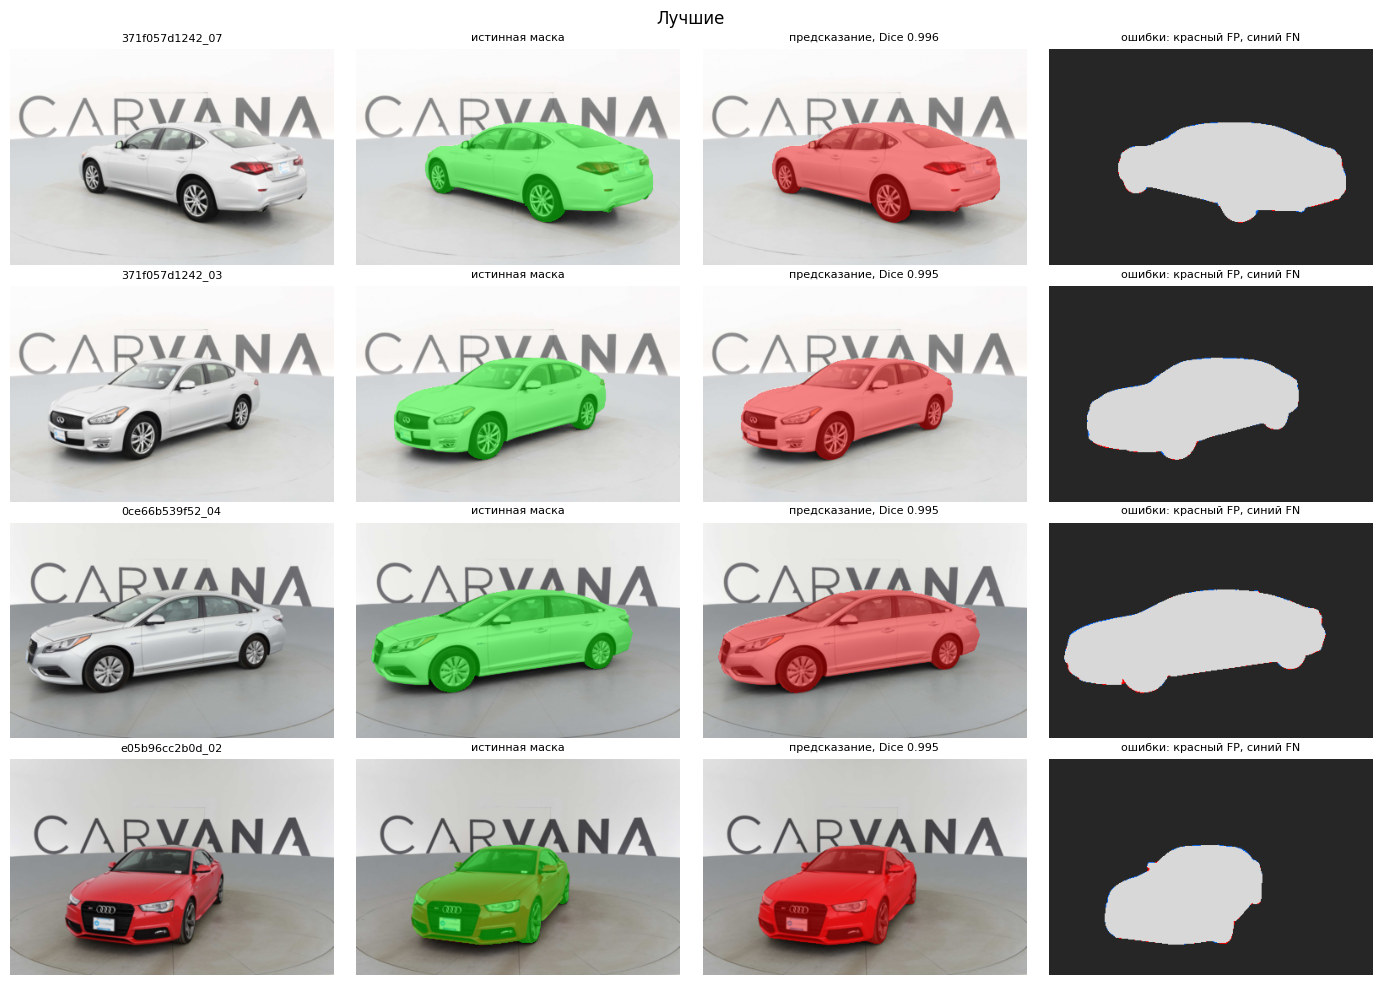

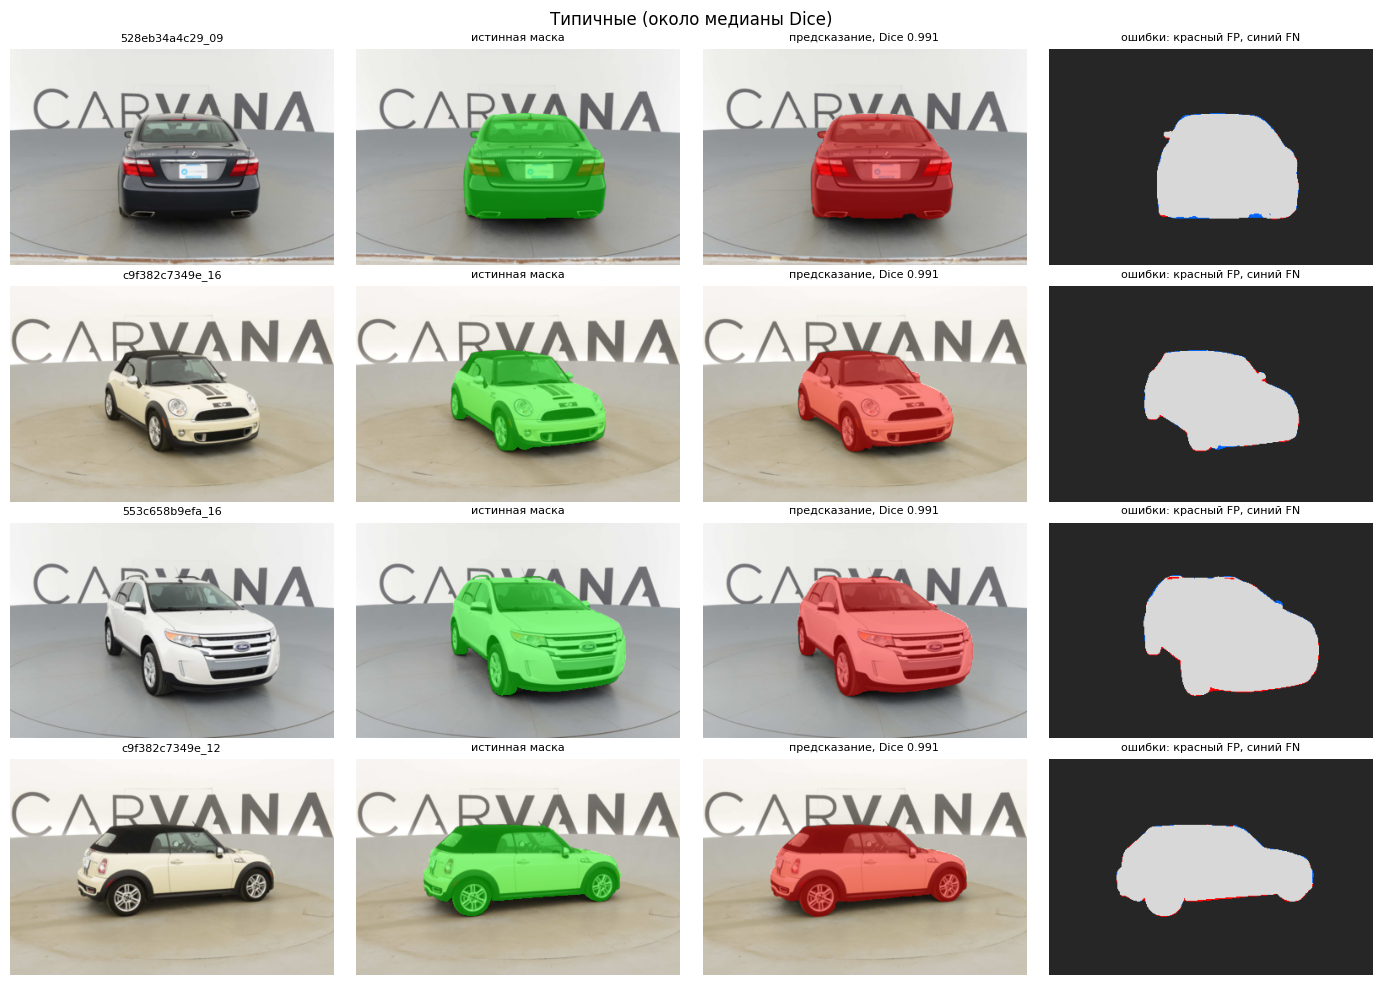

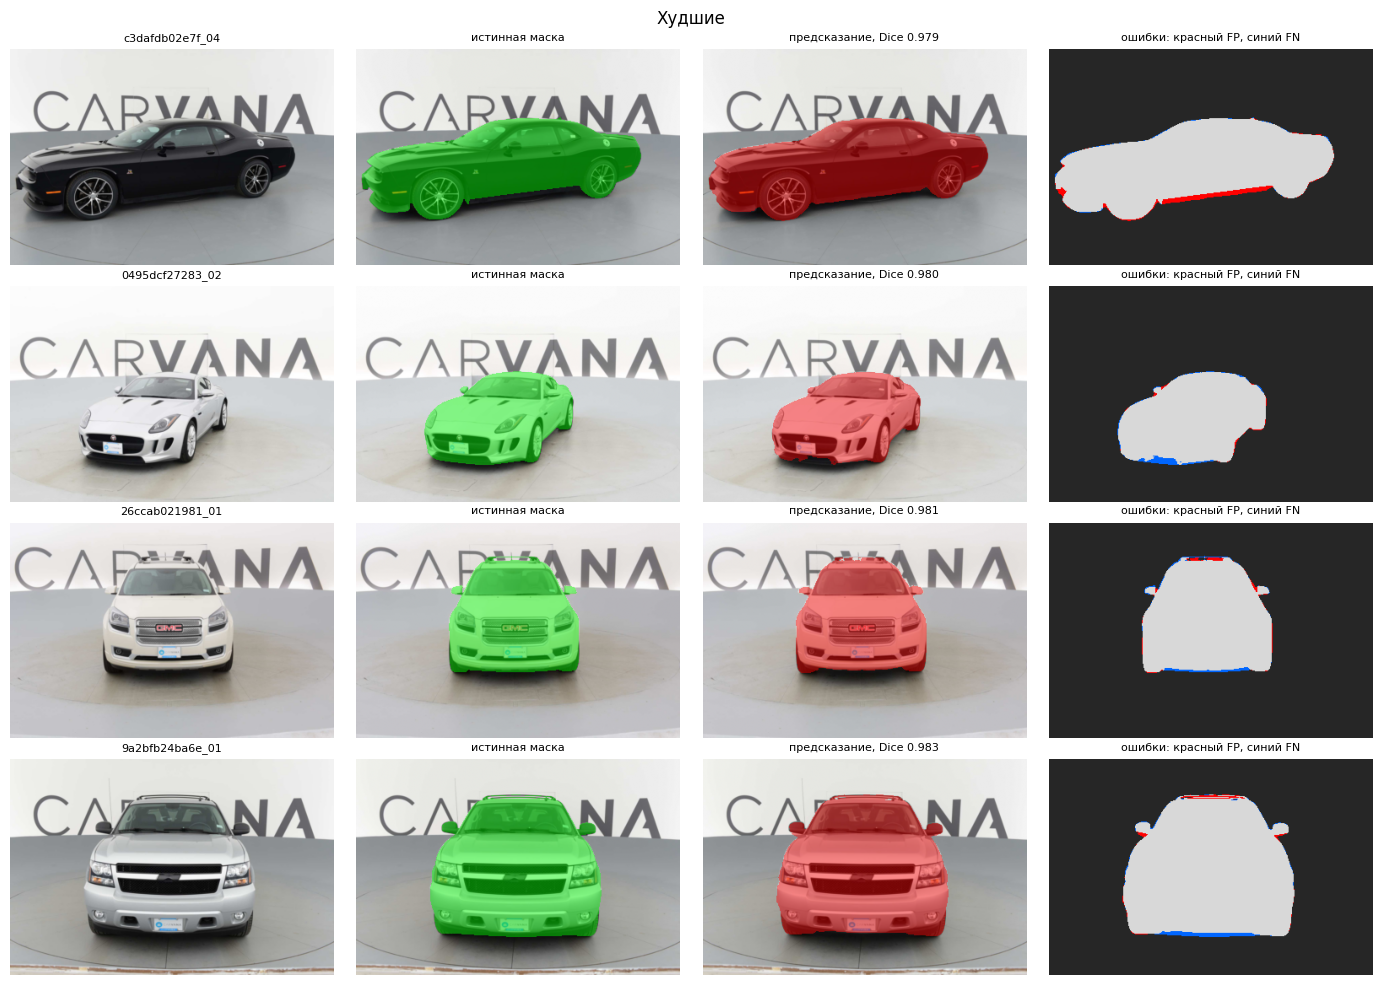

In [15]:
pt = P[BEST]['test'].float().numpy() > THR
gt = msks[te_idx].astype(bool)
inter, s = (pt & gt).sum((1, 2)), pt.sum((1, 2)) + gt.sum((1, 2))
df = pd.DataFrame({'id': np.array(ids)[te_idx], 'dice': 2 * inter / s, 'iou': inter / (s - inter), 'gt_frac': gt.mean((1, 2)), 'pred_frac': pt.mean((1, 2))})
print(df[['dice', 'iou']].describe().round(4).to_string())
order = df.dice.argsort().values


def show(sel, title):
    fig, ax = plt.subplots(len(sel), 4, figsize=(14, 2.5 * len(sel)))
    for r, k in enumerate(sel):
        im = imgs[te_idx[k]]
        err = np.full((H, W, 3), 0.15)
        err[pt[k] & gt[k]] = 0.85; err[pt[k] & ~gt[k]] = (1, 0, 0); err[~pt[k] & gt[k]] = (0, 0.4, 1)
        for a, (v, t) in zip(ax[r], [(im, df.id[k]), (overlay(im, gt[k], (0, 1, 0)), 'истинная маска'),
                                     (overlay(im, pt[k]), f'предсказание, Dice {df.dice[k]:.3f}'), (err, 'ошибки: красный FP, синий FN')]):
            a.imshow(v); a.set_title(t, fontsize=8); a.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()


m = len(order) // 2
show(order[::-1][:4], 'Лучшие')
show(order[m - 2:m + 2], 'Типичные (около медианы Dice)')
show(order[:4], 'Худшие')

## 11. Границы, маленькие области, ложный foreground

In [16]:
st = ndi.generate_binary_structure(2, 1)
R_BAND, R_FAR = 3, 10
rec = []
comp_rec, fp_comp = [], []
for k in tqdm(range(len(te_idx))):
    g, p = gt[k], pt[k]
    band = ndi.binary_dilation(g, st, R_BAND) & ~ndi.binary_erosion(g, st, R_BAND, border_value=1)
    err = g ^ p
    far = (p & (ndi.distance_transform_edt(~g) > R_FAR)).sum()
    rec.append(dict(err=err.sum(), err_band=(err & band).sum(), band=band.sum(), fp=(p & ~g).sum(), fn=(g & ~p).sum(), fp_far=far))
    lab, n = ndi.label(g)
    for c in range(1, n + 1):
        cm = lab == c
        comp_rec.append((cm.sum(), p[cm].mean()))
    lab, n = ndi.label(p)
    for c in range(1, n + 1):
        cm = lab == c
        if not (g & cm).any():
            fp_comp.append(cm.sum())
E = pd.DataFrame(rec)
df['fp_far'] = E.fp_far.values

print(f'граница (полоса ±{R_BAND} px от контура): {E.band.sum() / (H * W * len(E)):.1%} пикселей, но {E.err_band.sum() / E.err.sum():.1%} всех ошибок')
print(f'ошибки: ложный foreground (FP) {E.fp.sum() / E.err.sum():.1%}, пропущенный foreground (FN) {E.fn.sum() / E.err.sum():.1%}')
print(f'FP дальше {R_FAR} px от истинной маски: {E.fp_far.sum() / E.fp.sum():.1%} всех FP; изображений с такими FP: {(E.fp_far > 0).sum()} из {len(E)}')
print(f'предсказанных компонент без пересечения с маской: {len(fp_comp)}, медианная площадь {np.median(fp_comp) if fp_comp else 0:.0f} px')

df['area_q'] = pd.qcut(df.gt_frac, 4, labels=['Q1 малые', 'Q2', 'Q3', 'Q4 крупные'])
print('\nDice по квартилям площади автомобиля в кадре:')
print(df.groupby('area_q').agg(gt_frac=('gt_frac', 'mean'), dice=('dice', 'mean'), iou=('iou', 'mean')).round(3).to_string())

cr = pd.DataFrame(comp_rec, columns=['area', 'recall'])
cr['размер, px'] = pd.cut(cr.area, [0, 100, 500, 2000, 10000, np.inf], labels=['<100', '100–500', '500–2000', '2000–10000', '>10000'])
print('\nкомпоненты истинной маски: доля покрытых предсказанием пикселей по размеру компоненты:')
print(cr.groupby('размер, px').recall.agg(['count', 'mean']).round(3).to_string())

  0%|          | 0/768 [00:00<?, ?it/s]

граница (полоса ±3 px от контура): 3.7% пикселей, но 98.2% всех ошибок
ошибки: ложный foreground (FP) 50.1%, пропущенный foreground (FN) 49.9%
FP дальше 10 px от истинной маски: 0.0% всех FP; изображений с такими FP: 4 из 768
предсказанных компонент без пересечения с маской: 39, медианная площадь 3 px

Dice по квартилям площади автомобиля в кадре:
            gt_frac   dice    iou
area_q                           
Q1 малые      0.151  0.990  0.980
Q2            0.188  0.991  0.982
Q3            0.217  0.991  0.982
Q4 крупные    0.277  0.991  0.982

компоненты истинной маски: доля покрытых предсказанием пикселей по размеру компоненты:
            count   mean
размер, px              
<100          241  0.177
100–500         0    NaN
500–2000        0    NaN
2000–10000      2  0.987
>10000        766  0.991


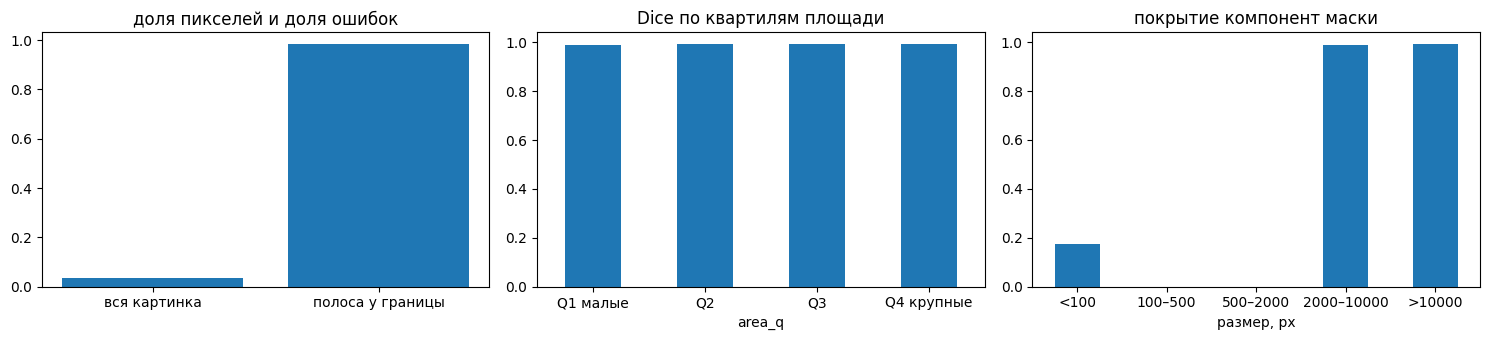

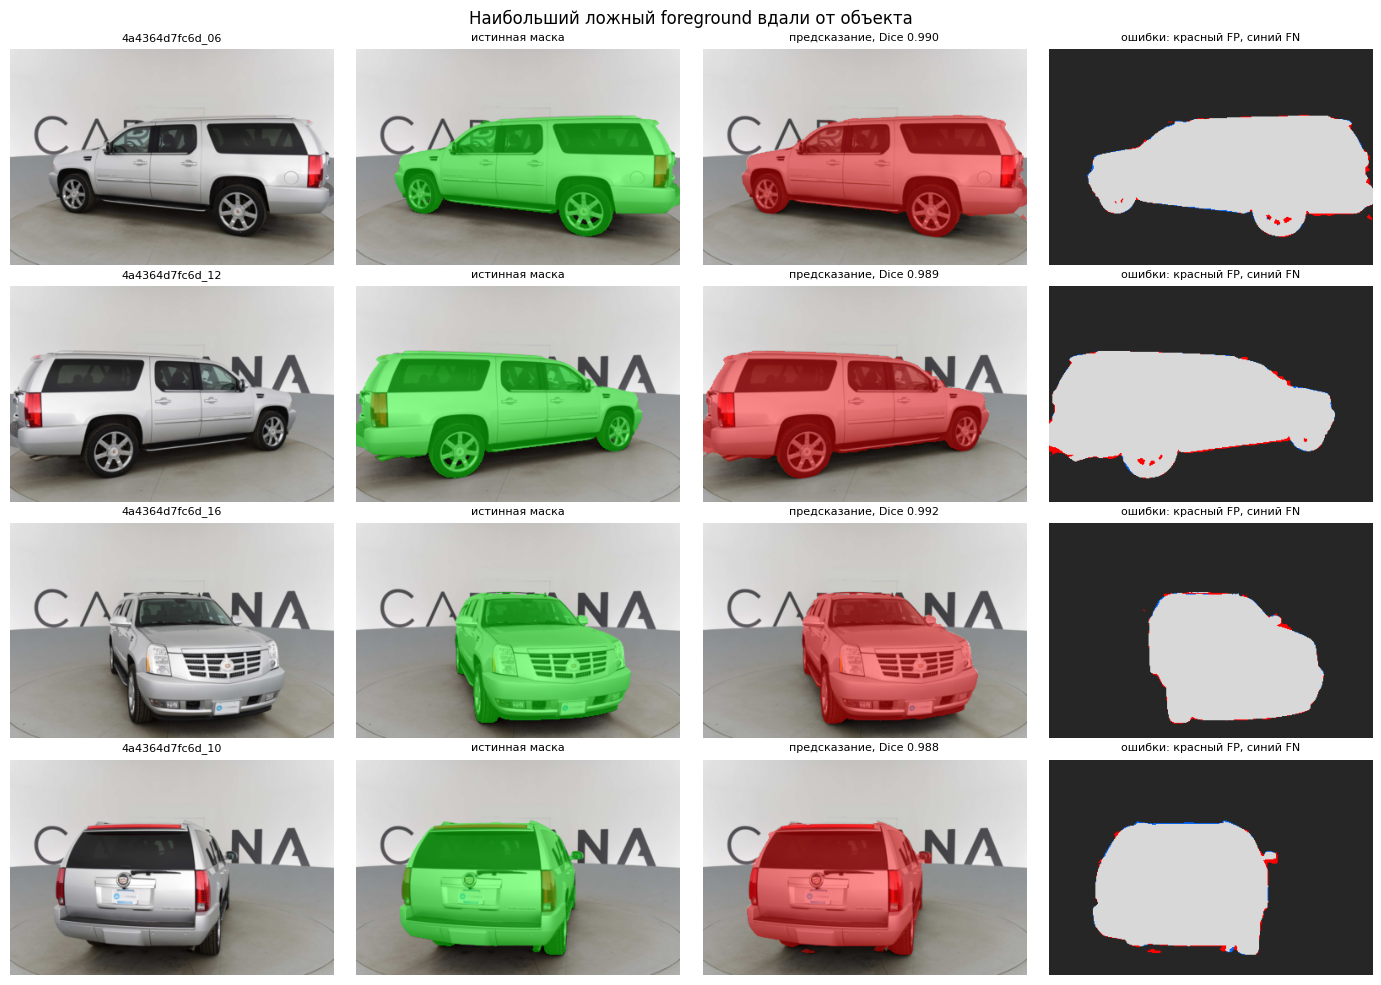

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].bar(['вся картинка', 'полоса у границы'], [E.band.sum() / (H * W * len(E)), E.err_band.sum() / E.err.sum()]); ax[0].set_title('доля пикселей и доля ошибок')
df.groupby('area_q').dice.mean().plot.bar(ax=ax[1], rot=0); ax[1].set_title('Dice по квартилям площади')
cr.groupby('размер, px').recall.mean().plot.bar(ax=ax[2], rot=0); ax[2].set_title('покрытие компонент маски')
plt.tight_layout(); plt.show()

show(df.fp_far.sort_values(ascending=False).index[:4].values, 'Наибольший ложный foreground вдали от объекта')

Сюда после запуска записать выводы по четырём пунктам: какая функция потерь лучше и на сколько; где концентрируются ошибки (граница, тонкие детали, фон); что общего у худших изображений; как порог менял метрики.

## 12. Скорость inference и размер модели

In [18]:
best_model = models[BEST]


@torch.no_grad()
def bench(model, dev, bs, n, amp=False):
    model = model.to(dev).eval()
    x = torch.randn(bs, 3, H, W, device=dev)
    sync = torch.cuda.synchronize if dev == 'cuda' else (lambda: None)
    for _ in range(3):
        with torch.autocast(dev, dtype=torch.float16, enabled=amp): model(x)
    sync(); t0 = time.time()
    for _ in range(n):
        with torch.autocast(dev, dtype=torch.float16, enabled=amp): model(x)
    sync(); dt = (time.time() - t0) / n
    return dt / bs * 1000, bs / dt


rows = []
if DEVICE == 'cuda':
    for bs, amp in [(1, False), (1, True), (32, False), (32, True)]:
        ms_, fps = bench(best_model, 'cuda', bs, 30, amp)
        rows.append(dict(устройство='GPU', batch=bs, fp16=amp, мс_на_изображение=ms_, изображений_в_с=fps))
ms_, fps = bench(best_model.cpu(), 'cpu', 1, 10)
rows.append(dict(устройство='CPU', batch=1, fp16=False, мс_на_изображение=ms_, изображений_в_с=fps))
best_model.to(DEVICE)
print(pd.DataFrame(rows).round(2).to_string(index=False))
print(f'параметров: {sum(p.numel() for p in best_model.parameters()):,} | файл checkpoint: {os.path.getsize(WORK / f"{BEST}.pt") / 2**20:.2f} МБ | разрешение {H}x{W}')

устройство  batch  fp16  мс_на_изображение  изображений_в_с
       GPU      1 False               6.35           157.55
       GPU      1  True               3.49           286.25
       GPU     32 False               3.79           263.58
       GPU     32  True               2.04           490.67
       CPU      1 False             145.18             6.89
параметров: 1,942,577 | файл checkpoint: 7.46 МБ | разрешение 256x384
